In [18]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,date,region,max_temp,min_temp,humidity,wind_speed,pressure,rainfall,uv_index,max_temp_today,max_temp_yesterday,max_temp_2days_ago,avg_temp_3days,rainfall_3days,heatwave
0,2023-04-01,Delhi,41.318139,22.172661,48.817218,7.763360,1008.012521,2.911545,7.893319,41.318139,39.318139,37.318139,39.318139,1.455773,1
1,2023-04-01,Mumbai,36.837463,27.320432,71.789467,6.546080,1006.602285,0.737369,5.133950,36.837463,34.837463,32.837463,34.837463,0.368685,0
2,2023-04-01,Chennai,35.269616,29.541745,24.388796,10.308680,1004.761513,8.696767,9.642226,35.269616,33.269616,31.269616,33.269616,4.348384,0
3,2023-04-01,Kolkata,41.111402,26.505512,34.839215,13.419185,1014.754701,6.151971,9.051375,41.111402,39.111402,37.111402,39.111402,3.075985,1
4,2023-04-01,Jaipur,38.148387,26.722817,36.801578,17.091852,1007.487389,0.334984,9.176255,38.148387,36.148387,34.148387,36.148387,0.167492,0


In [19]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                1000 non-null   object 
 1   region              1000 non-null   object 
 2   max_temp            1000 non-null   float64
 3   min_temp            1000 non-null   float64
 4   humidity            1000 non-null   float64
 5   wind_speed          1000 non-null   float64
 6   pressure            1000 non-null   float64
 7   rainfall            1000 non-null   float64
 8   uv_index            1000 non-null   float64
 9   max_temp_today      1000 non-null   float64
 10  max_temp_yesterday  1000 non-null   float64
 11  max_temp_2days_ago  1000 non-null   float64
 12  avg_temp_3days      1000 non-null   float64
 13  rainfall_3days      1000 non-null   float64
 14  heatwave            1000 non-null   int64  
dtypes: float64(12), int64(1), object(2)
memory usage: 117.3+

,0
date,0
region,0
max_temp,0
min_temp,0
humidity,0
wind_speed,0
pressure,0
rainfall,0
uv_index,0
max_temp_today,0


In [20]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['region'] = le.fit_transform(df['region'])

In [24]:
df.drop('date', axis=1, inplace=True)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'max_temp',
    'min_temp',
    'humidity',
    'wind_speed',
    'pressure',
    'rainfall',
    'uv_index',
    'max_temp_yesterday',
    'max_temp_2days_ago',
    'avg_temp_3days'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

In [26]:
X = df.drop('heatwave', axis=1)
y = df['heatwave']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [31]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[106   0]
 [  0  94]]


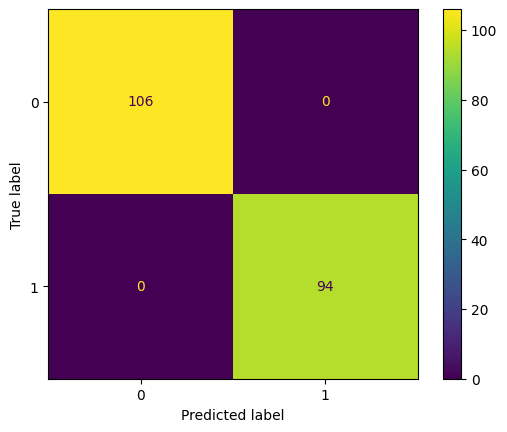

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.show()

In [35]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [38]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


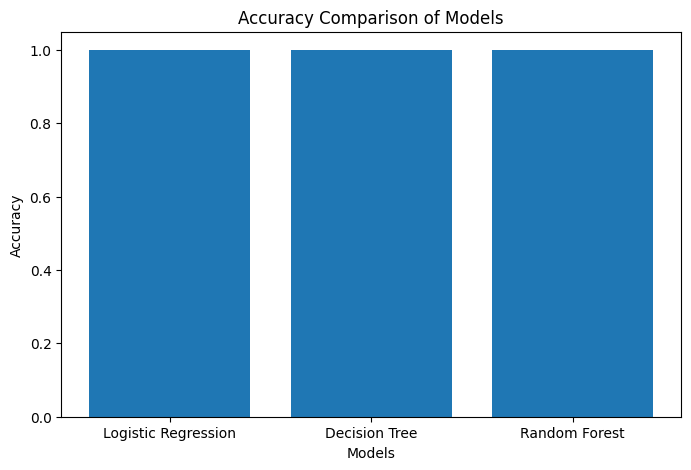

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy'])

plt.title('Accuracy Comparison of Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

In [40]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
10  max_temp_2days_ago    0.233126
9   max_temp_yesterday    0.197751
11      avg_temp_3days    0.190315
1             max_temp    0.189955
8       max_temp_today    0.183488
7             uv_index    0.001182
4           wind_speed    0.001055
6             rainfall    0.000906
2             min_temp    0.000829
0               region    0.000559
3             humidity    0.000526
5             pressure    0.000241
12      rainfall_3days    0.000069


In [41]:
df['heatwave'].value_counts()

,count
heatwave,
0,545
1,455


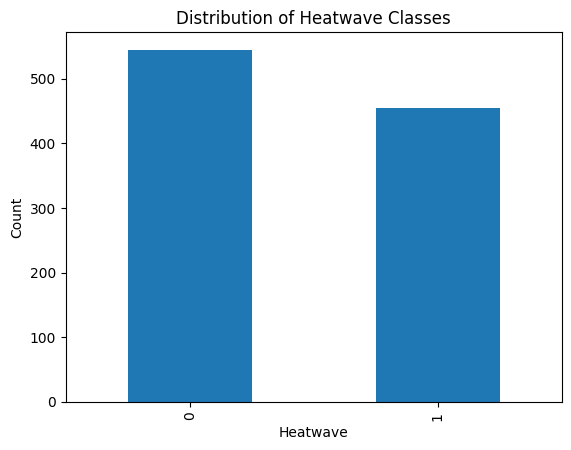

In [42]:
import matplotlib.pyplot as plt

df['heatwave'].value_counts().plot(kind='bar')

plt.title('Distribution of Heatwave Classes')
plt.xlabel('Heatwave')
plt.ylabel('Count')

plt.show()